In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

In [3]:
df= pd.read_csv("Data/houseprice.csv")

In [4]:
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,3,3.50,3413,37768,1.5,0,0,3,2850,563,1930,0,1079000
1,5,2.25,2023,31682,1.0,0,4,3,1343,680,1996,0,1190000
2,4,3.00,3051,33262,1.0,0,1,4,2440,611,1928,0,1289000
3,3,4.00,2497,32358,2.0,0,1,3,1966,531,1904,0,1091000
4,2,4.00,3226,15289,1.0,0,0,3,2725,501,1976,0,1182000


<function matplotlib.pyplot.show(close=None, block=None)>

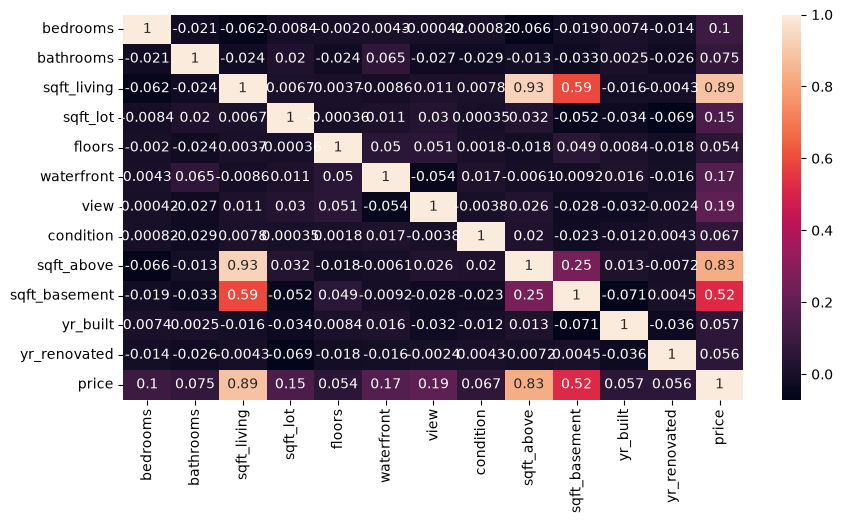

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(data=df.corr(),annot=True)
plt.show

In [6]:
x=df.iloc[:,:-1]

In [7]:
y=df["price"]

# Standardize feature to a common scale

In [8]:
sc=StandardScaler()
sc.fit(x)
x=pd.DataFrame(sc.transform(x),columns=x.columns)

In [9]:
x

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,-0.240656,1.121504,0.786192,0.975394,-0.264494,-0.160128,-0.719850,-0.292505,0.957749,-0.030155,-0.888697,-0.566534
1,1.669313,-0.209816,-0.438916,0.541758,-1.161085,-0.160128,2.468853,-0.292505,-0.637002,0.240408,1.005629,-0.566534
2,0.714329,0.588976,0.467135,0.654335,-1.161085,-0.160128,0.077326,0.811288,0.523875,0.080845,-0.946101,-0.566534
3,-0.240656,1.654033,-0.021145,0.589924,0.632096,-0.160128,0.077326,-0.292505,0.022275,-0.104155,-1.634947,-0.566534
4,-1.195641,1.654033,0.621376,-0.626264,-1.161085,-0.160128,-0.719850,-0.292505,0.825471,-0.173530,0.431591,-0.566534
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.195641,-1.541137,-0.966858,-0.438588,-1.161085,-0.160128,-0.719850,0.811288,-0.849706,-0.679968,1.120436,1.761747
996,1.669313,-0.476080,-0.446848,1.746546,0.632096,-0.160128,0.077326,-0.292505,-0.040161,-1.084656,0.804715,-0.566534
997,-1.195641,0.056448,1.439290,-1.035389,-1.161085,-0.160128,-0.719850,-1.396299,1.403264,0.709846,1.378754,-0.566534
998,1.669313,-1.008608,0.239741,1.510847,0.632096,-0.160128,2.468853,-1.396299,0.255085,0.071595,0.546398,-0.566534


In [10]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression ,Lasso ,Ridge

# Apply Linear Regression Model

In [12]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100

92.65445469687126

## Find Error

In [13]:
print(mean_squared_error(y_test,lr.predict(x_test)))
print(mean_absolute_error(y_test,lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

6143118284.7580385
62532.25442448942
78378.04721194602


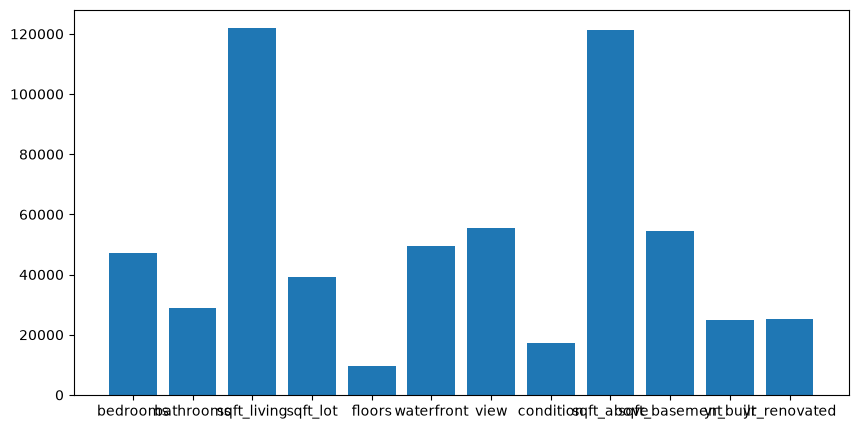

In [14]:
plt.figure(figsize=(10,5))
plt.bar(x.columns,lr.coef_)
plt.show()

# Apply Lasso Regression

In [15]:
la=Lasso(alpha=0.5)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

92.65443118140763

In [16]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,la.predict(x_test))))

6143137950.86432
62532.40820983304
78378.17266857093


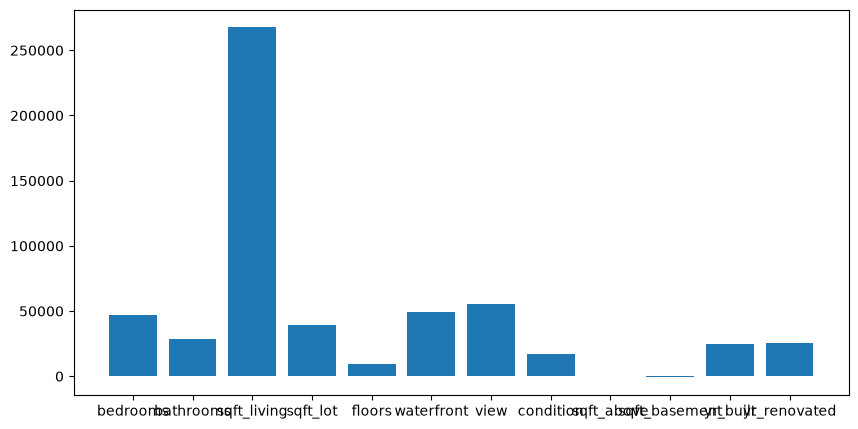

In [17]:
plt.figure(figsize=(10,5))
plt.bar(x.columns,la.coef_)
plt.show()

# Apply Ridge regression

In [18]:
ri=Ridge(alpha=10)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)*100

92.69085764401741

In [19]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))

6112674308.034163
62489.23728765424
78183.59359887574


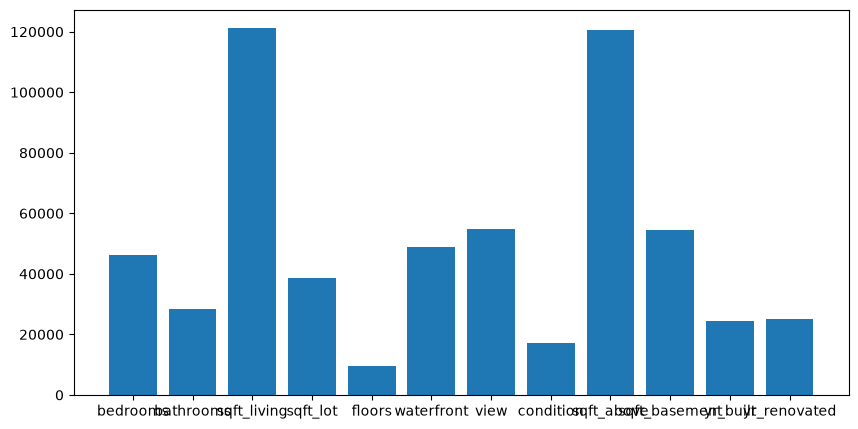

In [20]:
plt.figure(figsize=(10,5))
plt.bar(x.columns,ri.coef_)
plt.show()